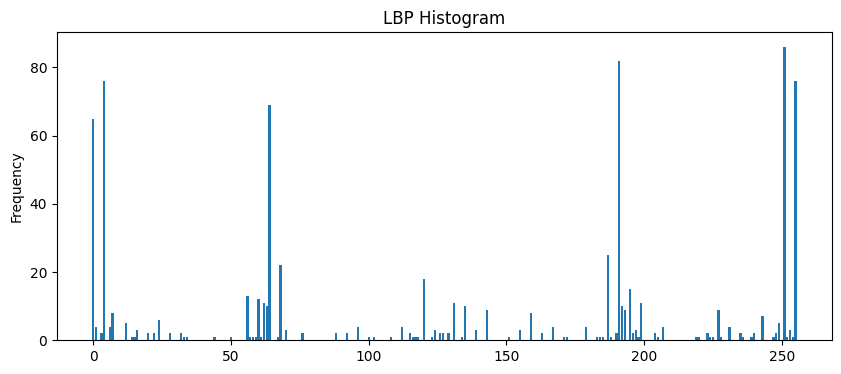

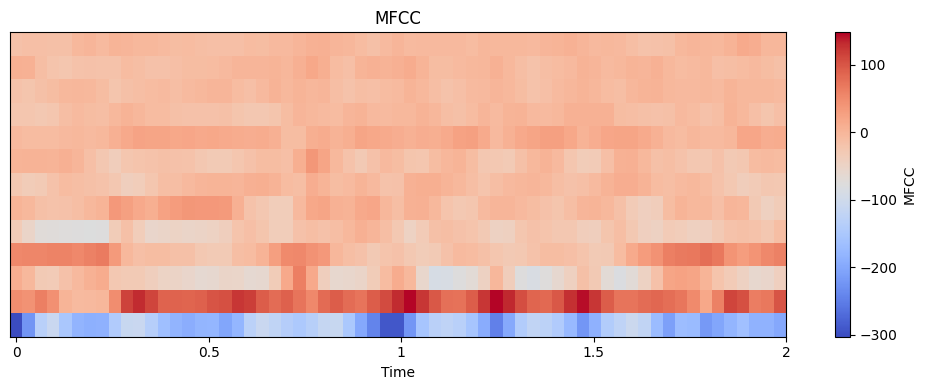

In [4]:
import librosa
import librosa.display
import matplotlib.pyplot as plt
import numpy as np
from skimage.feature import local_binary_pattern

audio_path = r"E:\Pythonfile\Voice-Activity-Detect\data\processed\speech\non-mixed\10.wav"

# Load audio
y, sr = librosa.load(audio_path, sr=16000)

# Lấy 2 giây đầu
duration = 2
y_2s = y[:int(sr * duration)]

# Tính MFCC
mfcc = librosa.feature.mfcc(
    y=y_2s,
    sr=sr,
    n_mfcc=13
)
delta = librosa.feature.delta(mfcc)

# delta-delta
delta2 = librosa.feature.delta(mfcc, order=2)

# ghép feature
feat_all = mfcc.T

lbp = local_binary_pattern(
                feat_all,
                P=8,
                R=1,
                method="default"
            )

hist, _ = np.histogram(
    lbp.ravel(),
    bins=256,
    range=(0, 256)
)
plt.figure(figsize=(10,4))
plt.bar(np.arange(256), hist)
plt.title("LBP Histogram")
plt.ylabel("Frequency")
plt.show()

# Vẽ biểu đồ
plt.figure(figsize=(10, 4))
librosa.display.specshow(
    feat_all.T,
    x_axis="time",
    sr=sr
)
plt.colorbar(label="MFCC")
plt.title("MFCC")
plt.tight_layout()
plt.show()

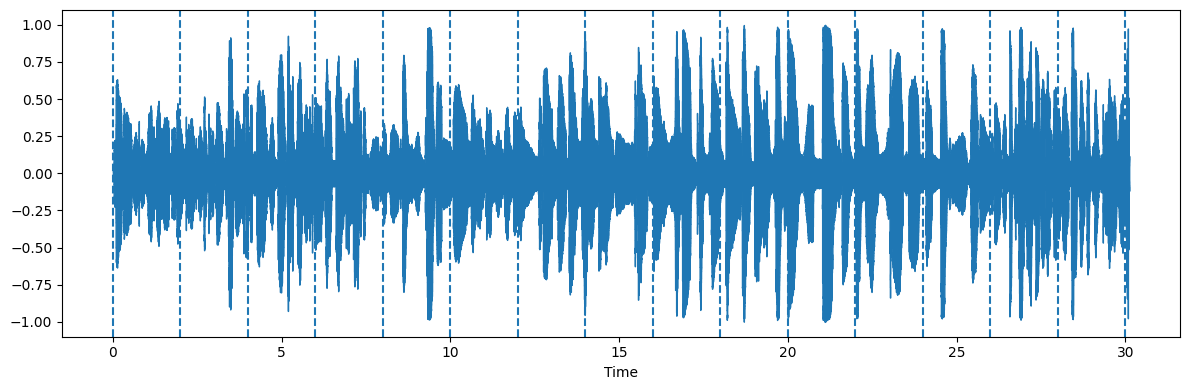

In [11]:
import librosa
import librosa.display
import matplotlib.pyplot as plt
import numpy as np

audio_path = "E:/PythonFile/Project/Voice-Activity-Detect/data/processed/musan/speech/non-mixed/10.wav"

# Load audio
y, sr = librosa.load(audio_path, sr=16000)

# Tính thời gian
duration = len(y) / sr

plt.figure(figsize=(12,4))

# Vẽ waveform
librosa.display.waveshow(y, sr=sr)

# Vẽ các đường chia mỗi 2s
segment = 2
for t in np.arange(0, duration, segment):
    plt.axvline(x=t, linestyle="--")

# plt.title("Waveform with 2-second segmentation")
# plt.xlabel("Time (s)")
# plt.ylabel("Amplitude")

plt.tight_layout()
plt.show()

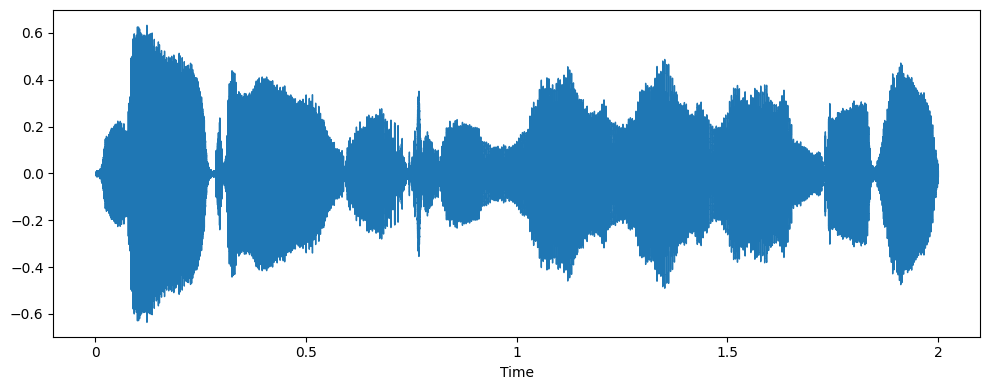

In [12]:
import librosa
import librosa.display
import matplotlib.pyplot as plt

audio_path = "E:/PythonFile/Project/Voice-Activity-Detect/data/processed/musan/speech/non-mixed/10.wav"


# Load audio
y, sr = librosa.load(audio_path, sr=16000)

# Lấy 2 giây đầu
y_2s = y[: int(sr * 2)]

# Vẽ waveform
plt.figure(figsize=(10,4))
librosa.display.waveshow(y_2s, sr=sr)

# plt.title("Waveform of first 2 seconds")
# plt.xlabel("Time (s)")
# plt.ylabel("Amplitude")

plt.tight_layout()
plt.show()